In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
from IPython.display import clear_output
from src.dataset_loaders_final import get_vectors_discrete_toy
from src.utils import get_pca_models
from src import utils
from src.train_final import train_toy_discrete, train_toy_continuous
import wandb
from torch.utils.data import TensorDataset, DataLoader
import yaml
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt

## 1. Parameters.

Possible ```DATASET_NAME``` values are: ```twitter```, ```wiki-gigaword```, ```bone_marrow```

In [7]:
SOURCE_DIM   = 2  #38 (bone_marrow)
TARGET_DIM   = 3
MAX_ITERS    = 10000
TOY_TYPE     = f'toy_{SOURCE_DIM}d_{TARGET_DIM}d'
METHOD_NAME  = 'AlignGW'
DEVICE       = 'cpu'
SEED         = 13
COST_DISCRETE= 'euclidean'
N_CLUSTERS   = 10

config = {'dataset':dict(#DATASET_NAME         = DATASET_NAME,
                         DEVICE               = DEVICE,
                         TOY_TYPE             = TOY_TYPE,
                         SOURCE_DIM           = SOURCE_DIM,
                         TARGET_DIM           = TARGET_DIM,
                         N_CLUSTERS_SOURCE    = 10,
                         N_CLUSTERS_TARGET    = 10,
                         N_SAMPLES            = 1024,
                         SEED                 = SEED,
                         NORMALIZE_VECS       = False
                          ),
          
          'training':dict(TRAIN_TYPE      = 'discrete',
                          METHOD_NAME     = METHOD_NAME,
                          MAX_ITERS       = MAX_ITERS,
                          COST_DISCRETE   = COST_DISCRETE,
                          ),
          #===============================RegGW===============================
          #'model_specific':dict(HIDDEN_SIZES_MLP = [512, 256, 256],
          #                      EPS_FIT          = 0.01,
          #                      EPS_REG          = 0.001,
          #                      LAMBDA           = 1,
          #                      MOVER_LR         = 1e-4
          #                     ),

          #===============================FlowGW===============================
          #'model_specific':dict(HIDDEN_SIZES_MLP = [256, 256, 256, 256],
          #                      EPS              = 1e-3,
          #                      N_FREQ           = 128,
          #                      MOVER_LR         = 1e-4,
          #                      )
          
          #===============================AlignGW===============================
          #===============================StructuredGW===============================
          
          'model_specific':dict(EPS = 7e-4,
                               ),
           }



## 2. Loading dataset.

torch.Size([1024, 2])
torch.Size([1024, 3])


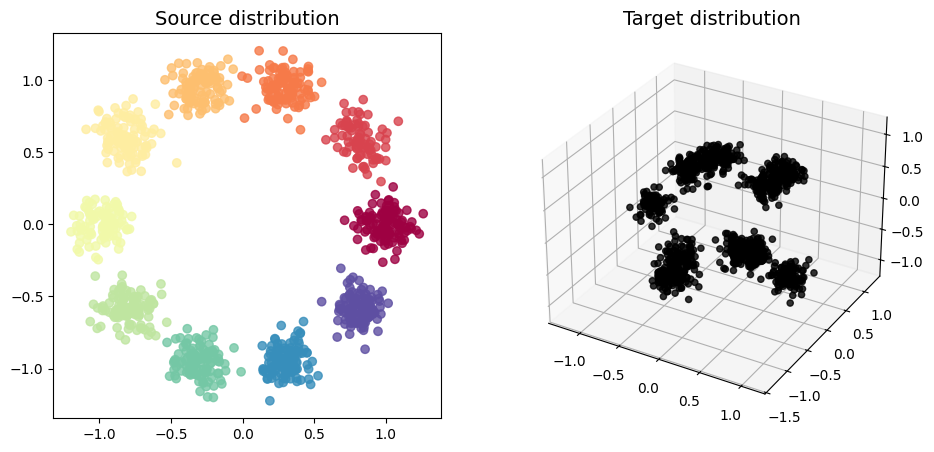

In [8]:

#train_sampler = get_samplers_toy(config)
#source_vectors, target_vectors, labels = train_sampler.sample(1024)

source_vectors, target_vectors, labels = get_vectors_discrete_toy(config)
#source_vectors, labels = source_sampler.sample_with_labels(1024)
#target_vectors = target_sampler.sample(1024)

print(source_vectors.shape)
print(target_vectors.shape)

figure = plt.figure(figsize=(11,5))

if TOY_TYPE == 'toy_3d_2d':
    ax1 = figure.add_subplot(1, 2, 1, projection='3d')
    ax2 = figure.add_subplot(1, 2, 2, projection=None)
    
if TOY_TYPE == 'toy_2d_3d':
    ax1 = figure.add_subplot(1, 2, 1, projection=None)
    ax2 = figure.add_subplot(1, 2, 2, projection='3d')

ax1.scatter(*source_vectors.cpu().T, c=labels.cpu().numpy(), cmap="Spectral", alpha=.8)
ax1.set_title('Source distribution', fontsize=14)
ax2.scatter(*target_vectors.cpu().T, c='black', alpha=.8)
ax2.set_title('Target distribution', fontsize=14)

plt.show()

## 3. Training.

  0%|          | 0/10000 [00:00<?, ?it/s]

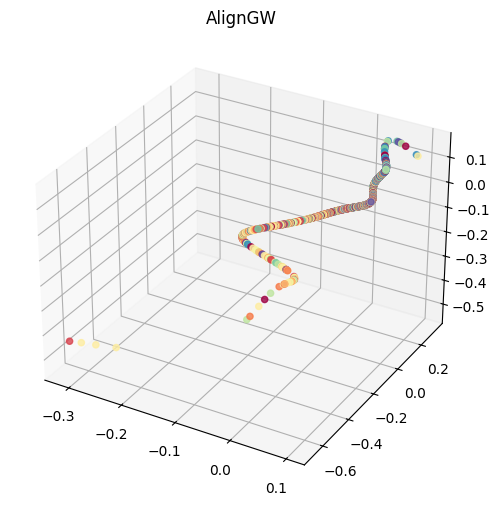

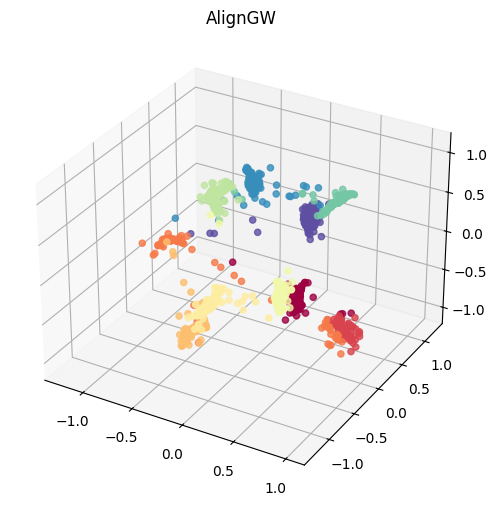

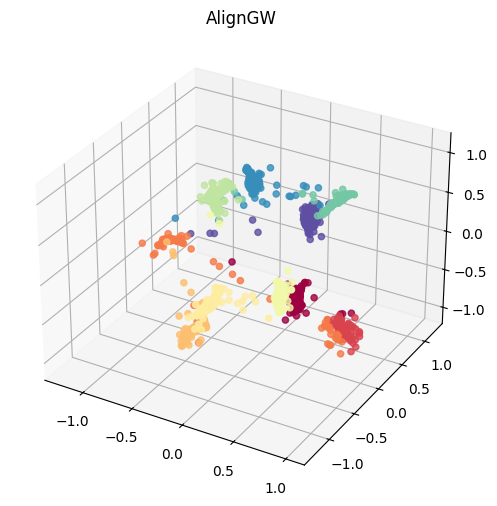

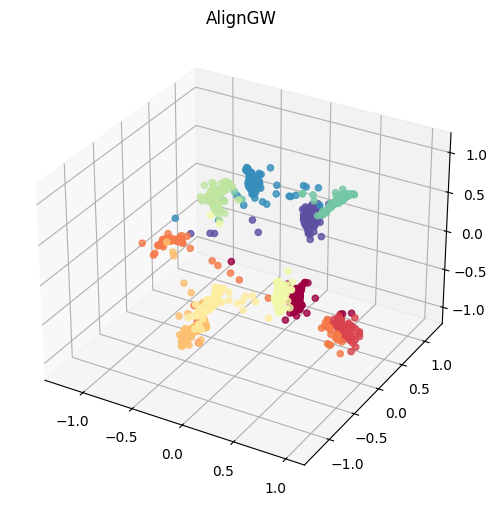

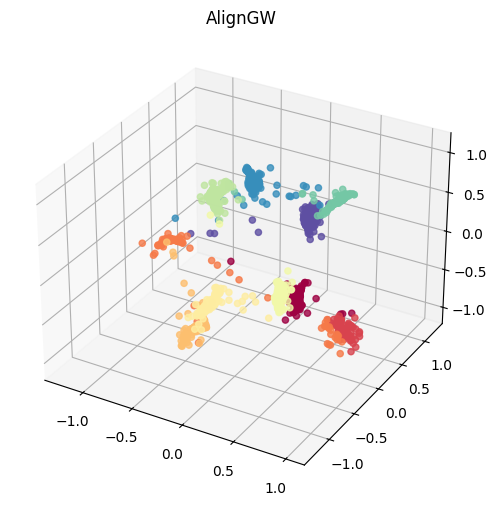

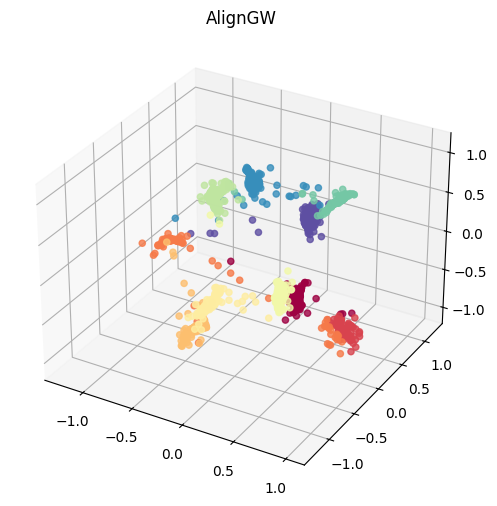

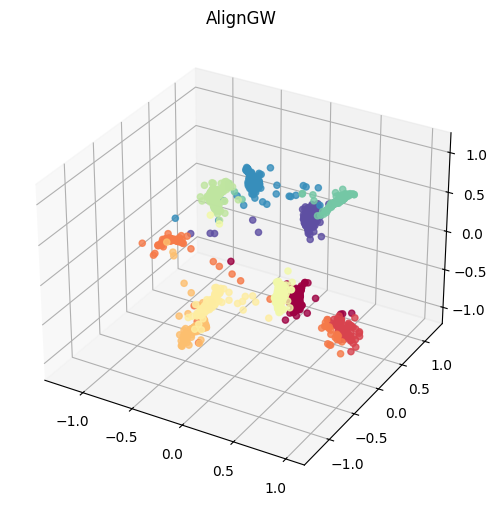

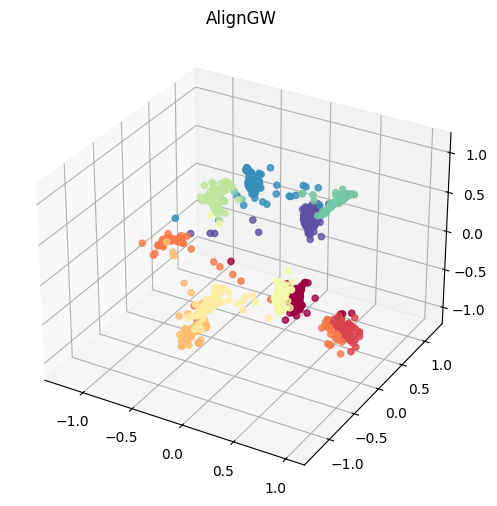

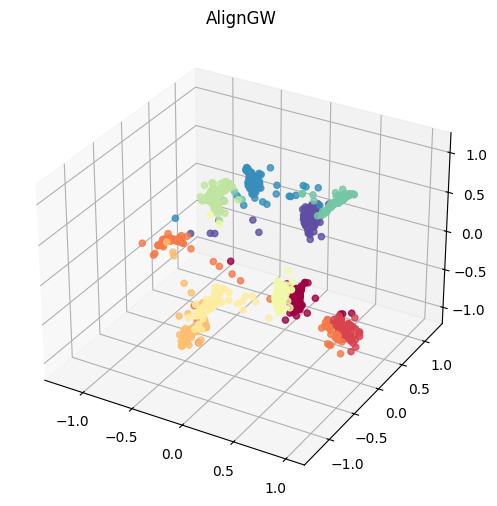

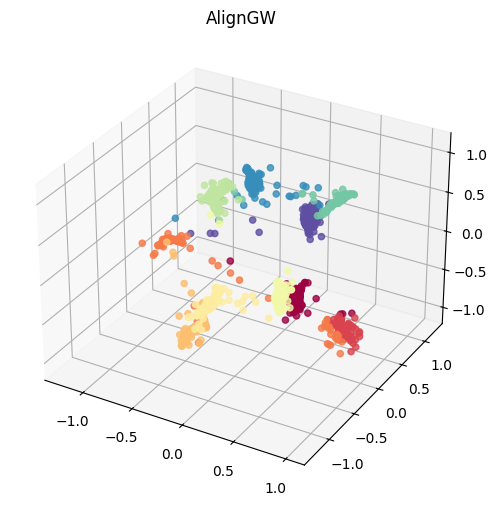

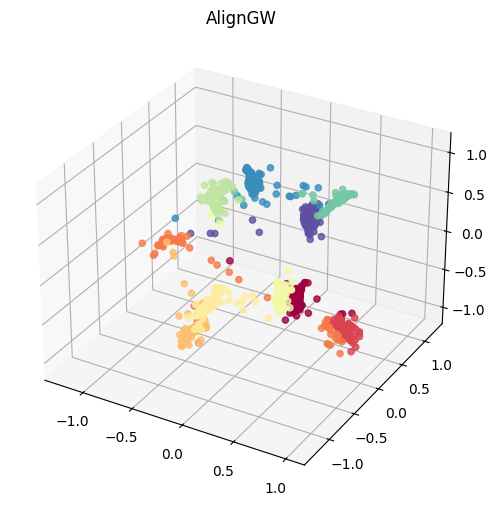

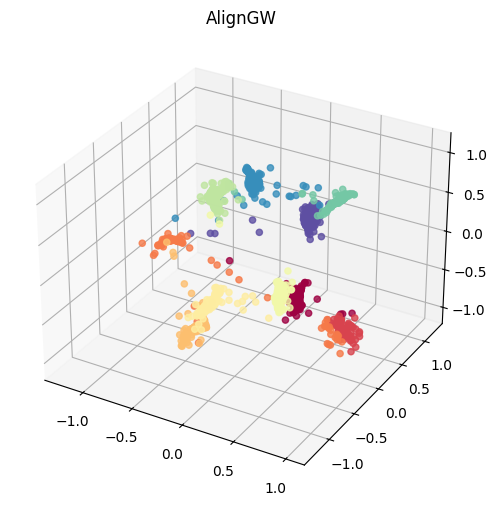

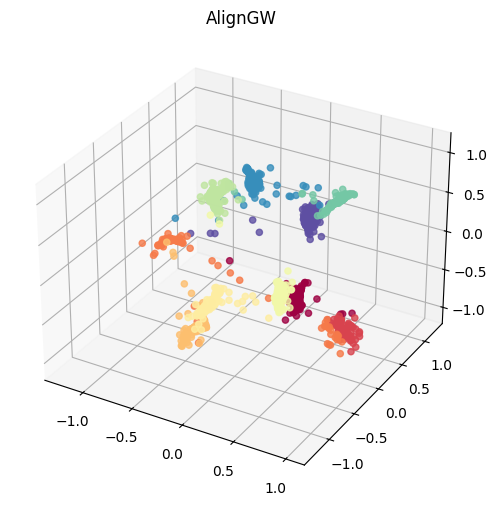

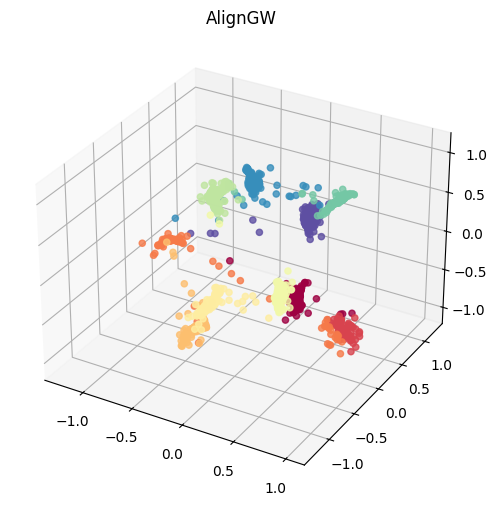

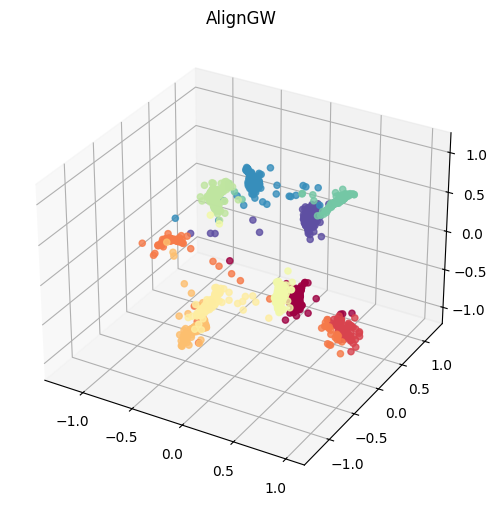

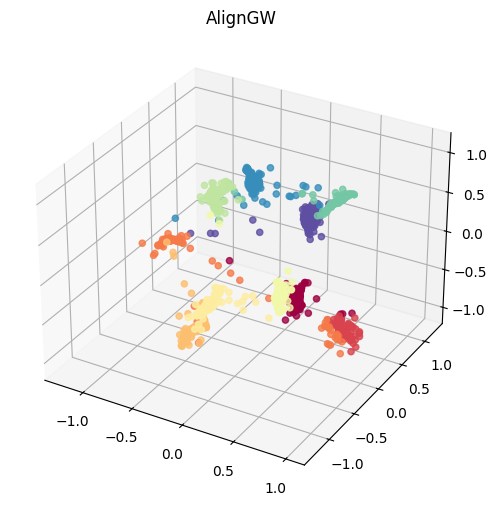

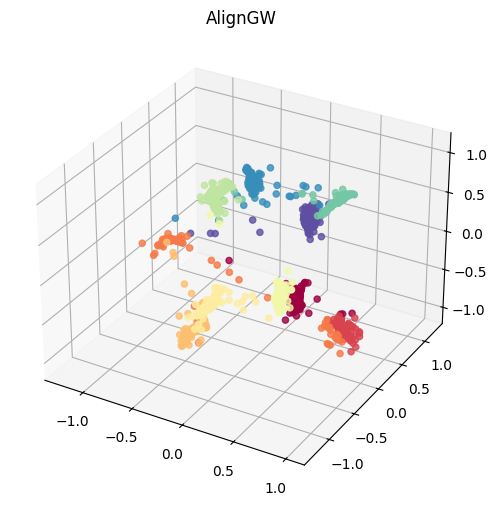

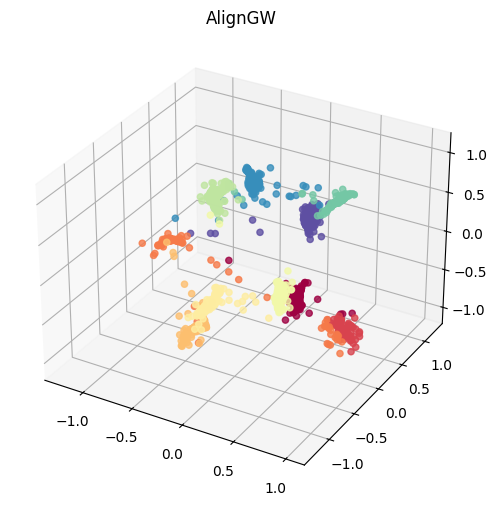

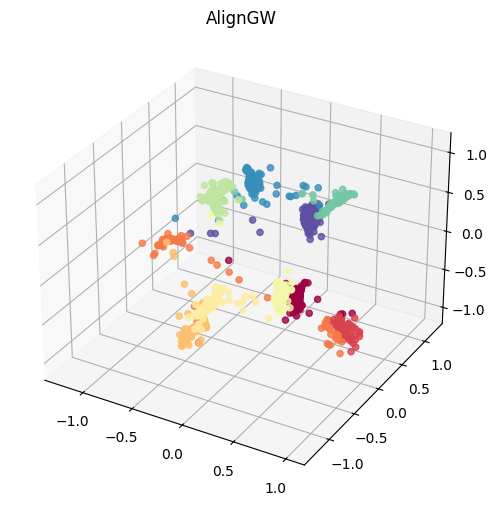

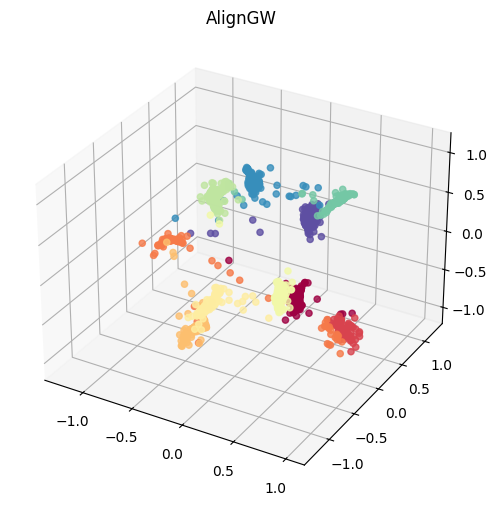

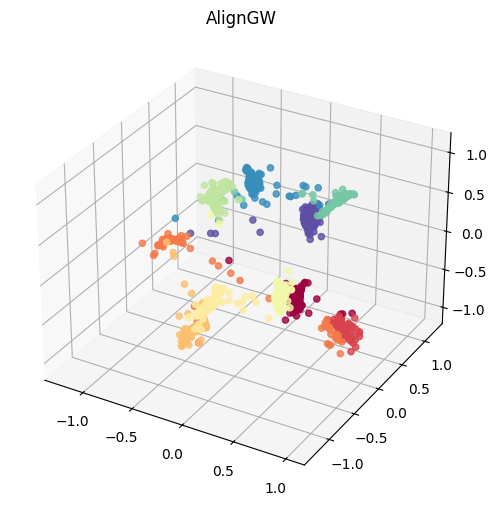

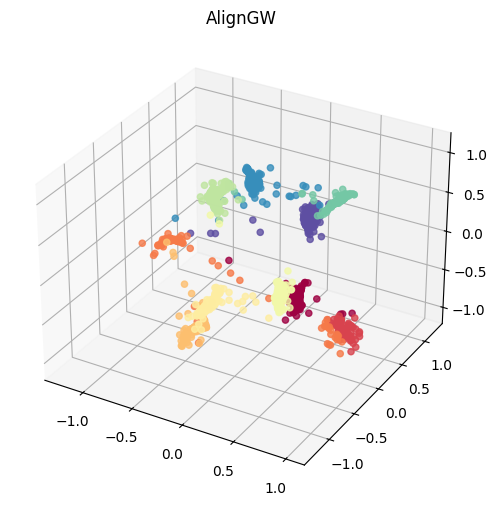

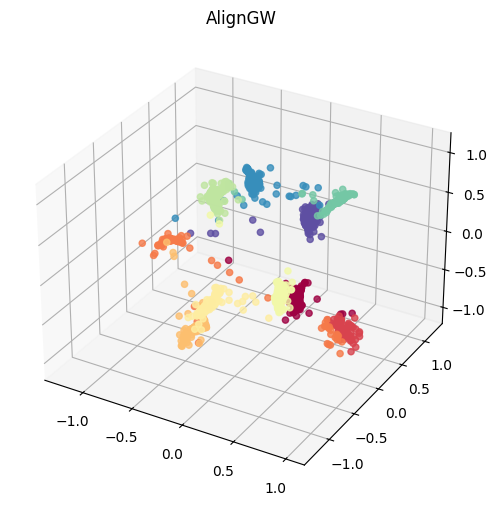

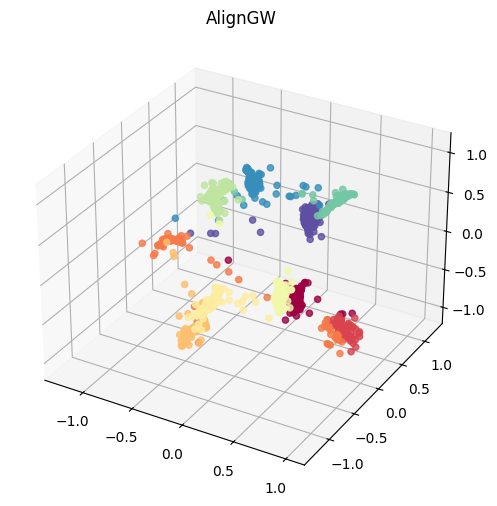

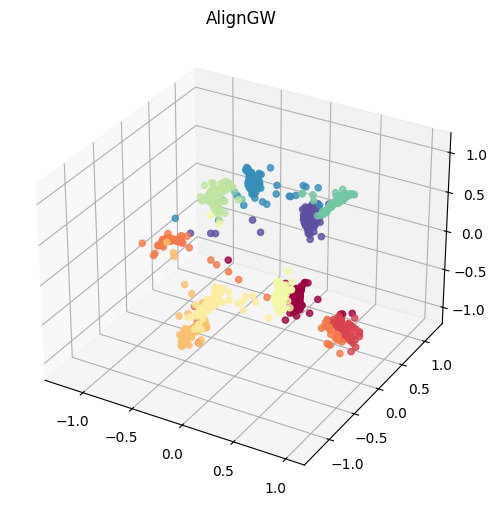

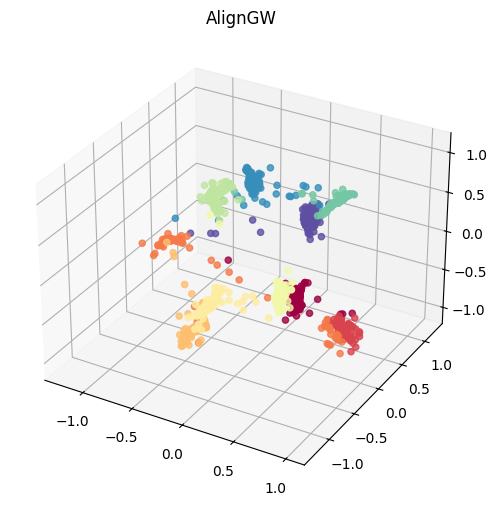

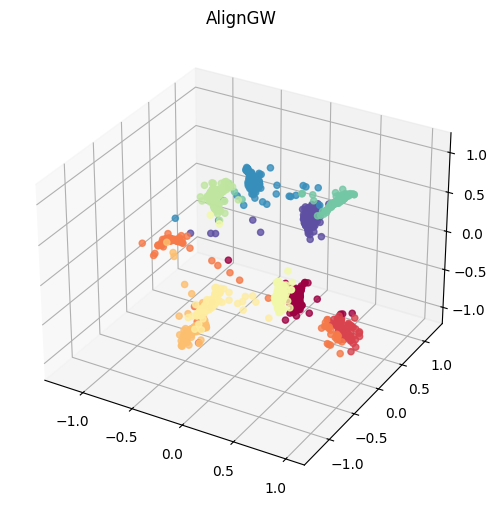

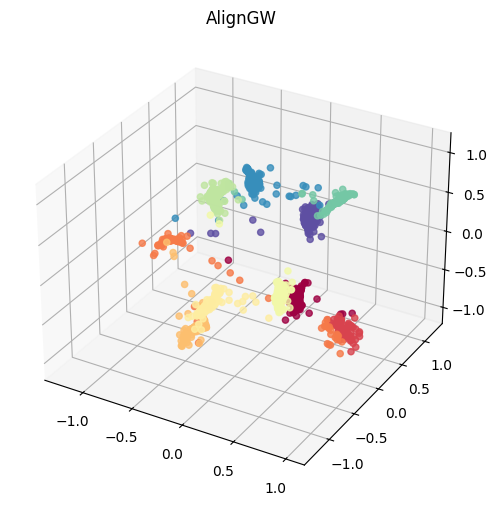

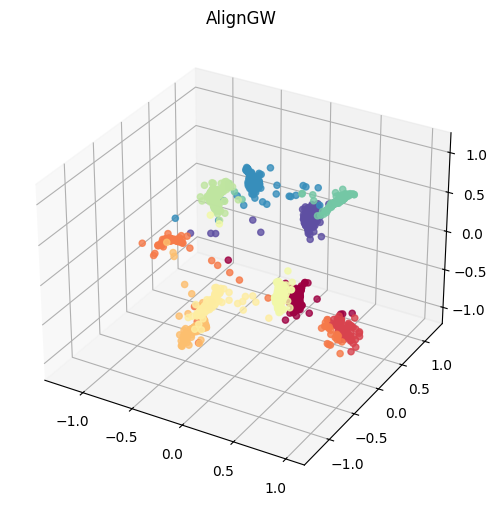

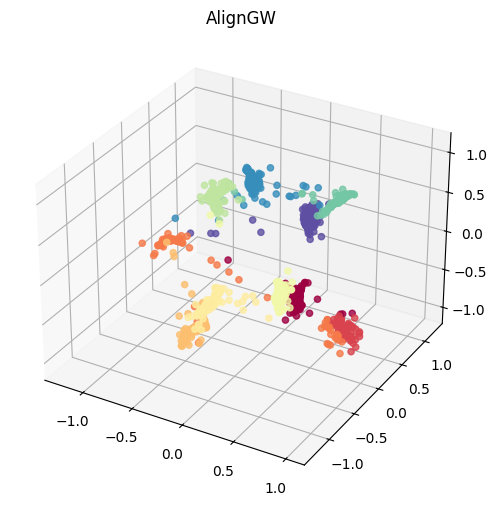

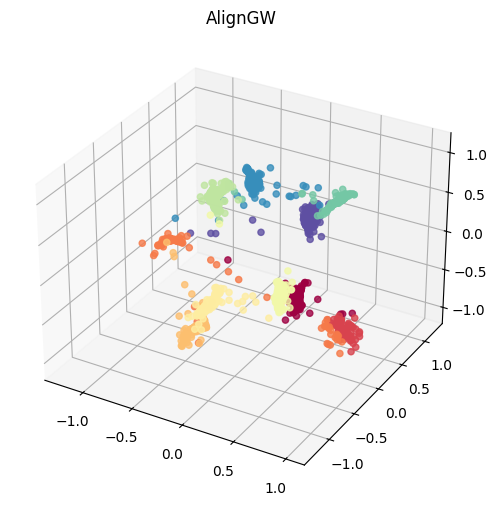

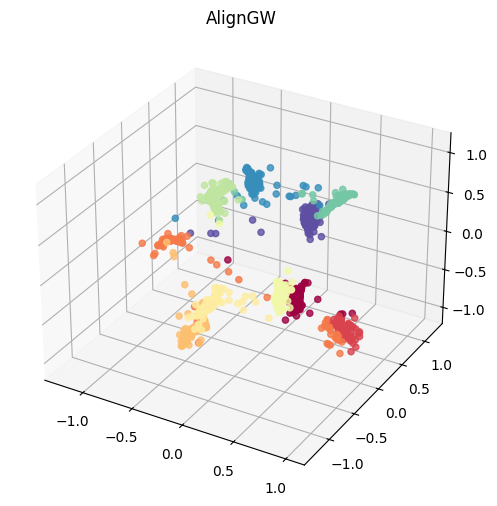

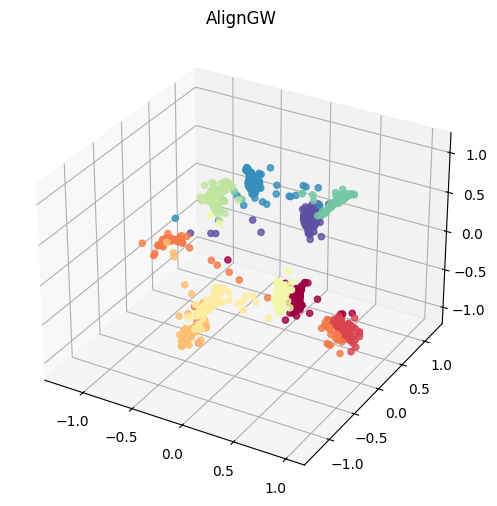

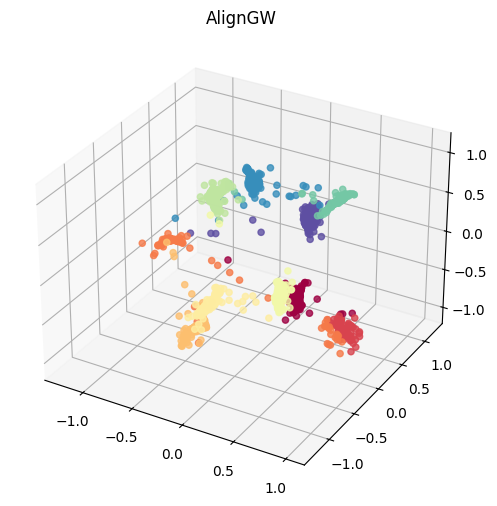

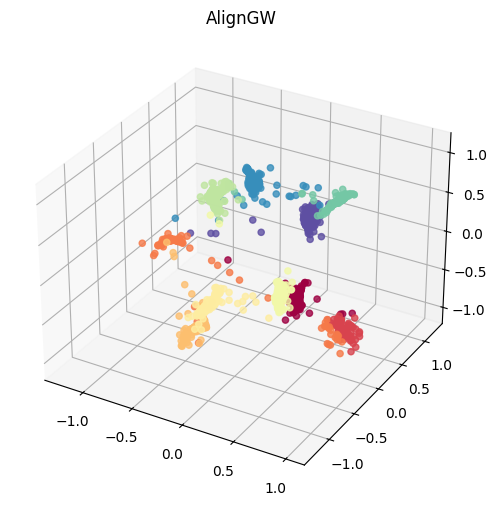

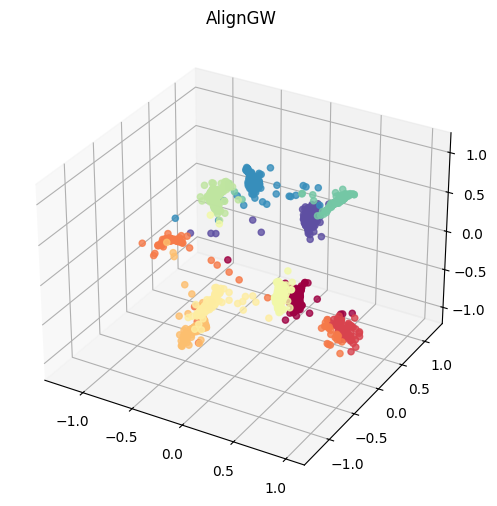

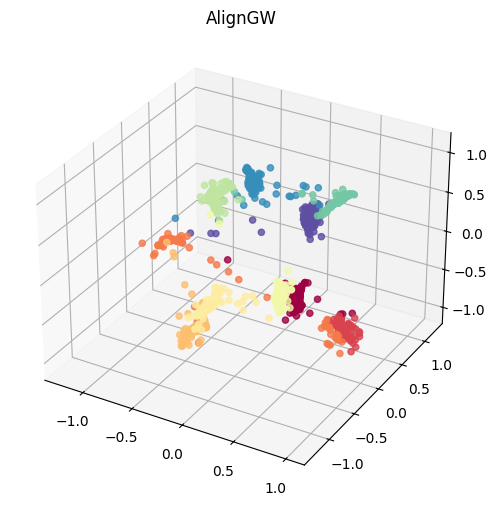

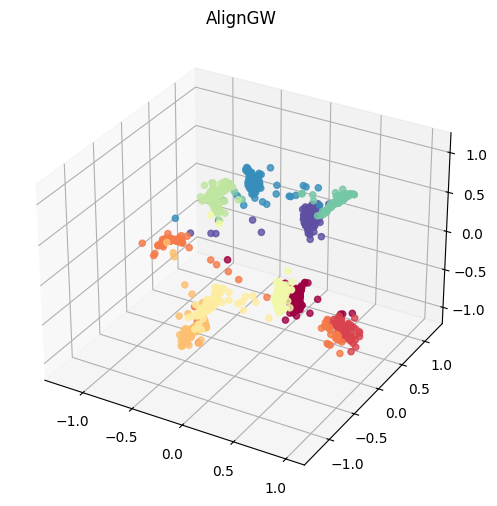

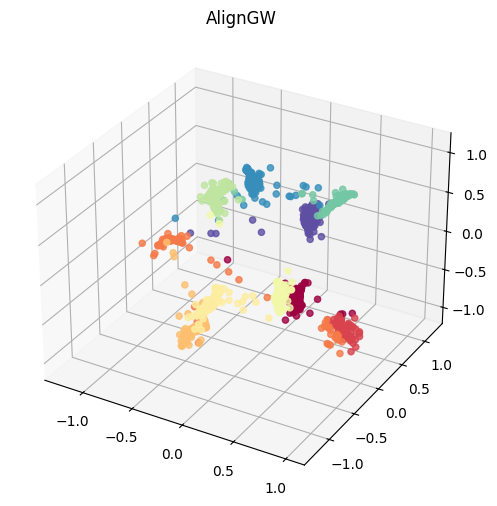

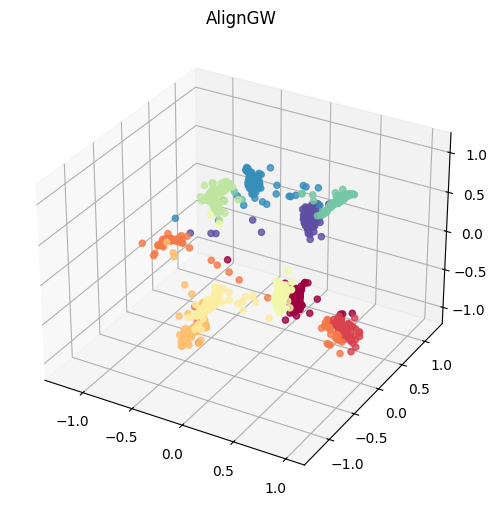

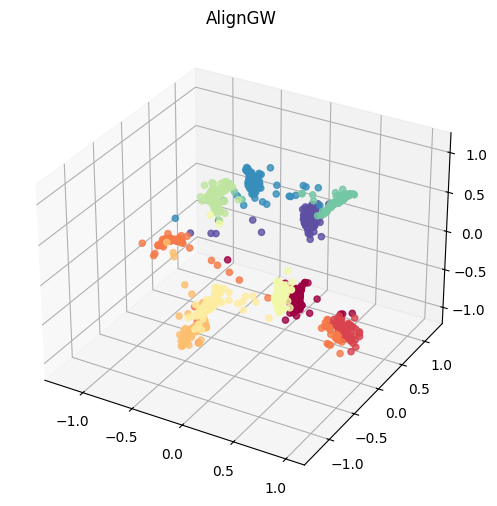

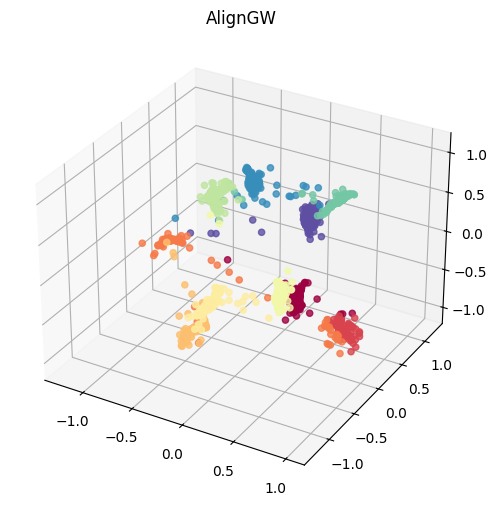

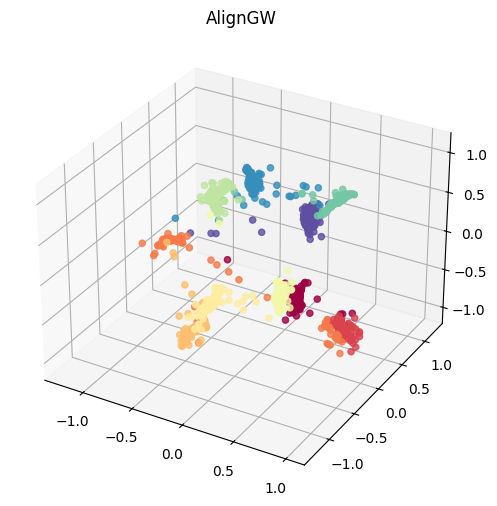

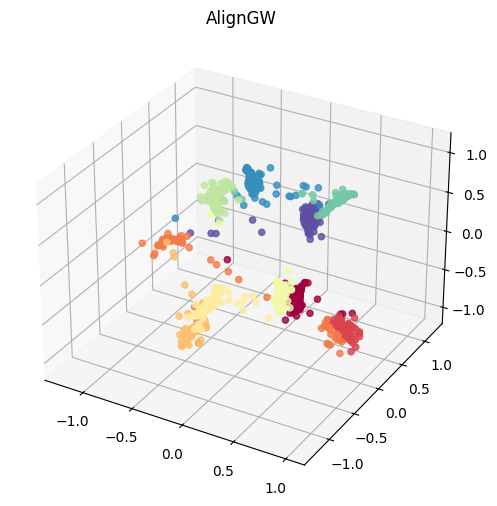

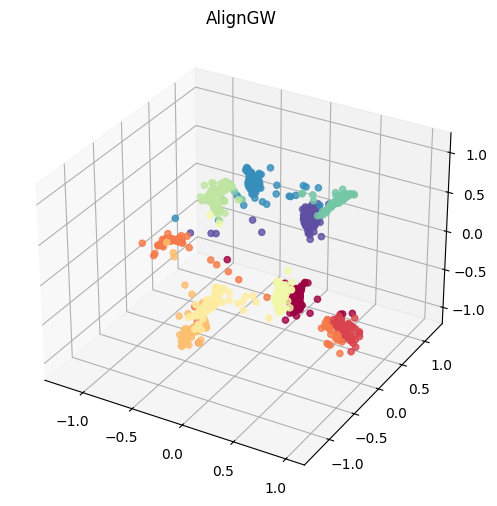

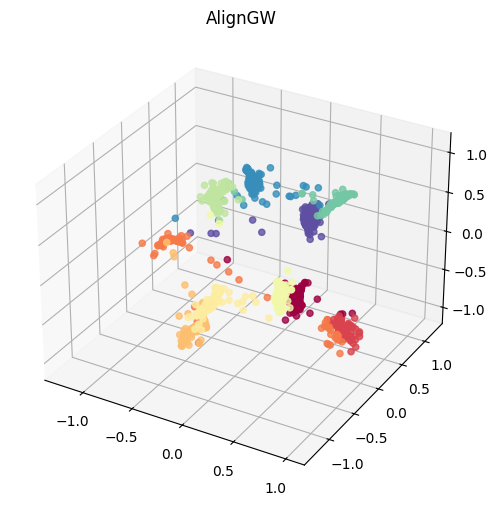

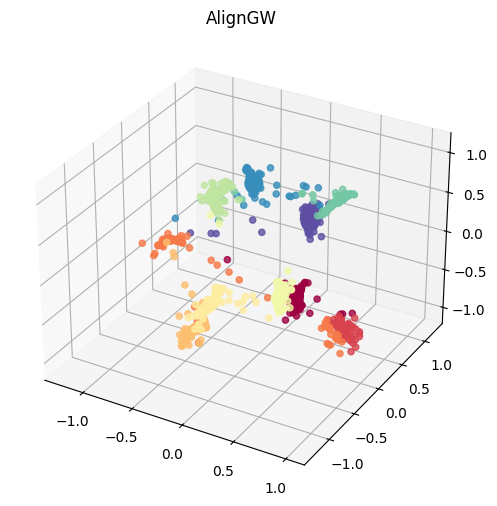

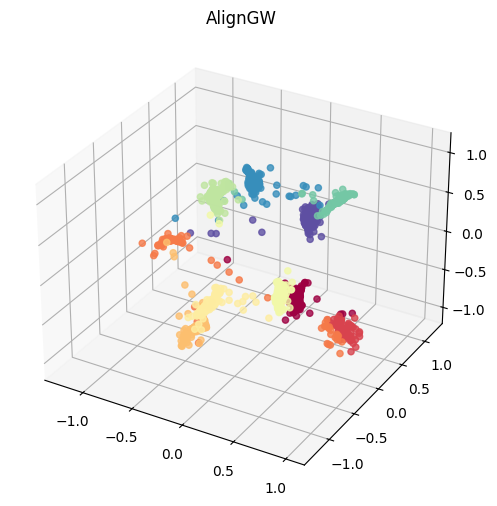

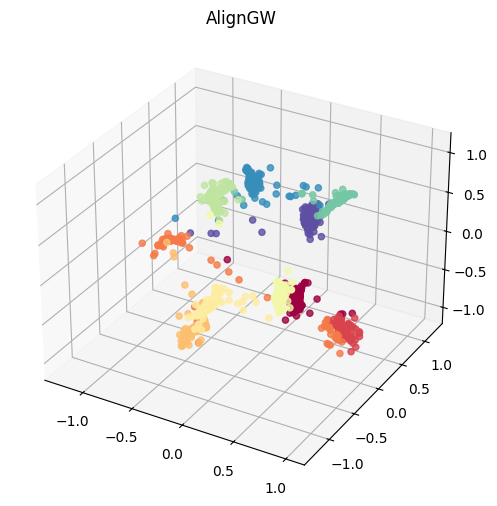

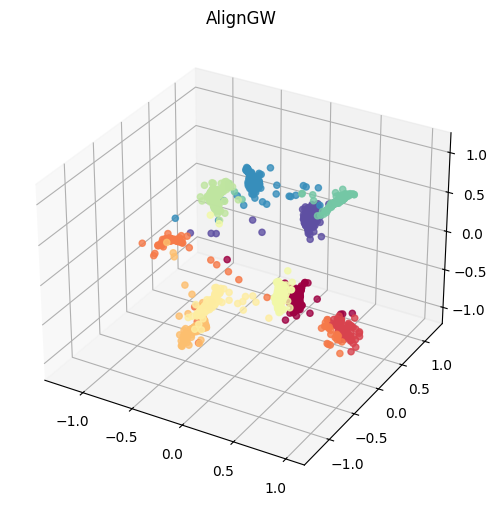

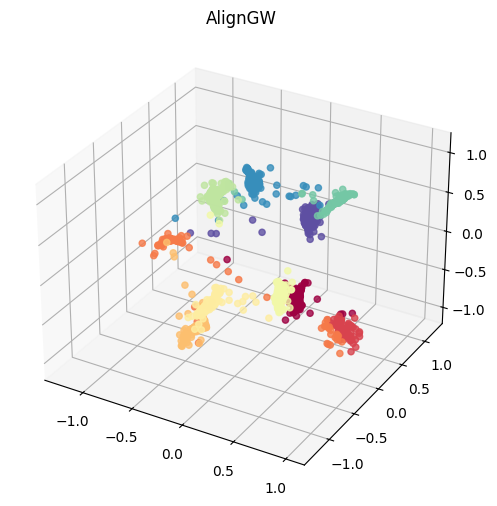

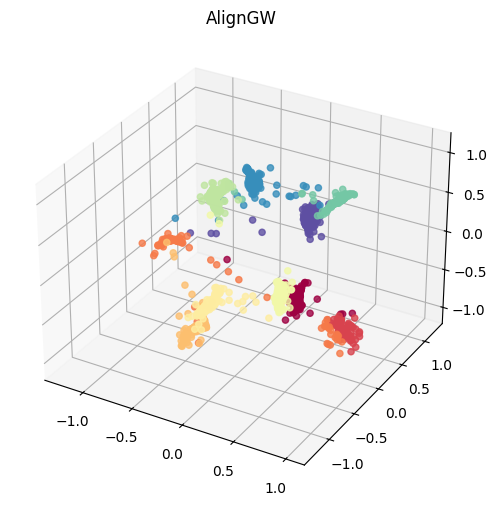

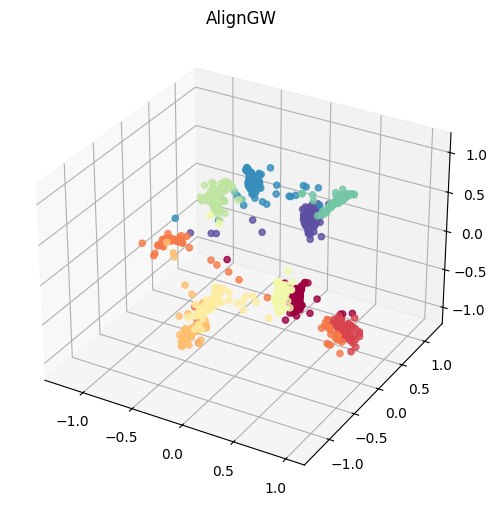

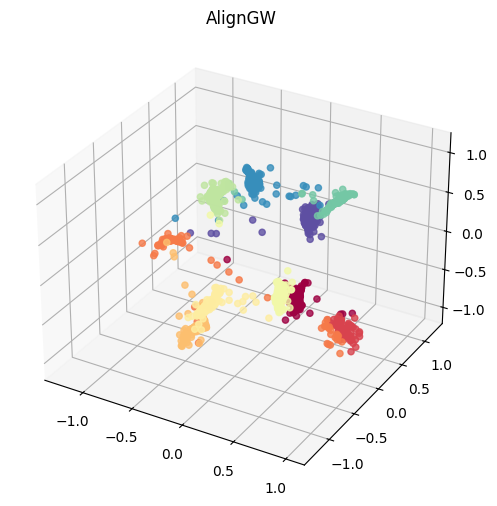

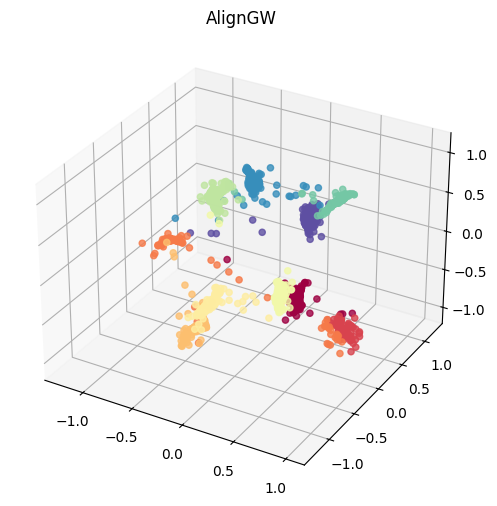

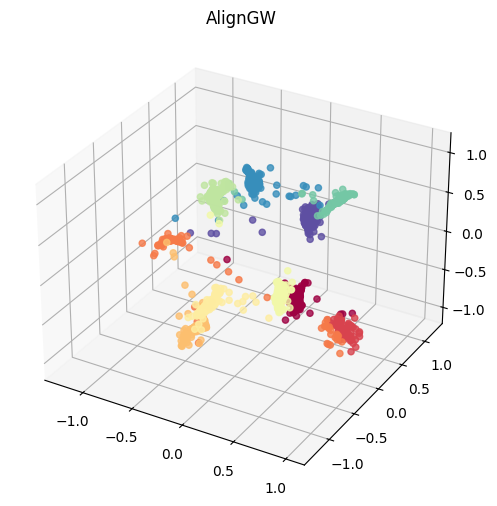

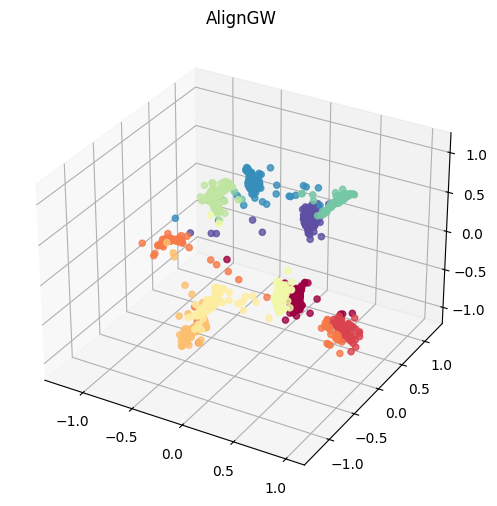

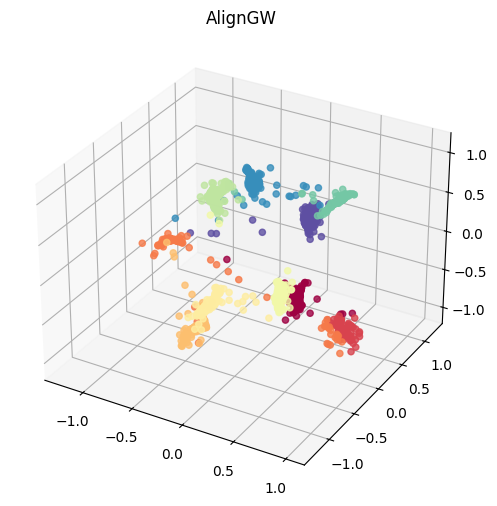

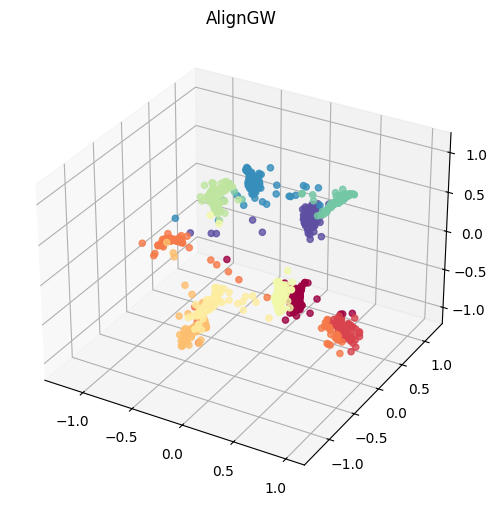

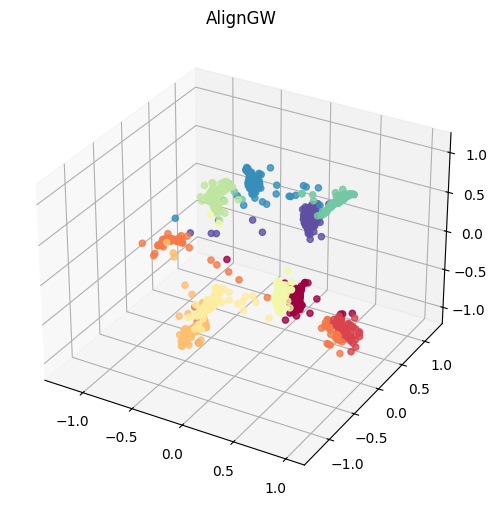

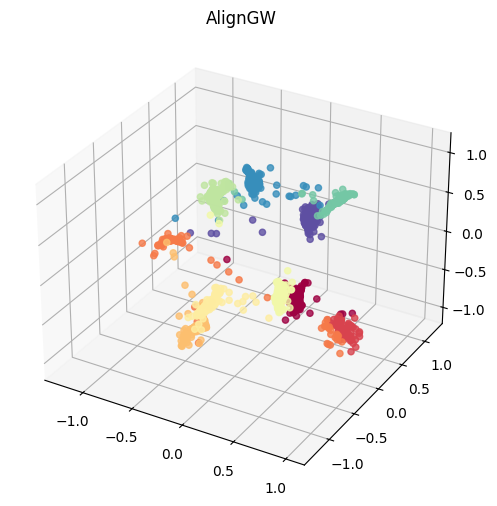

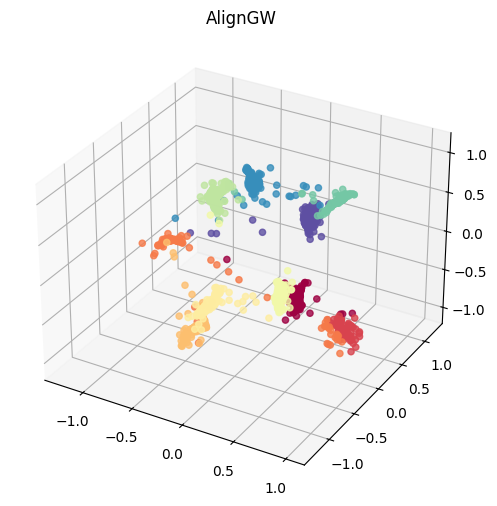

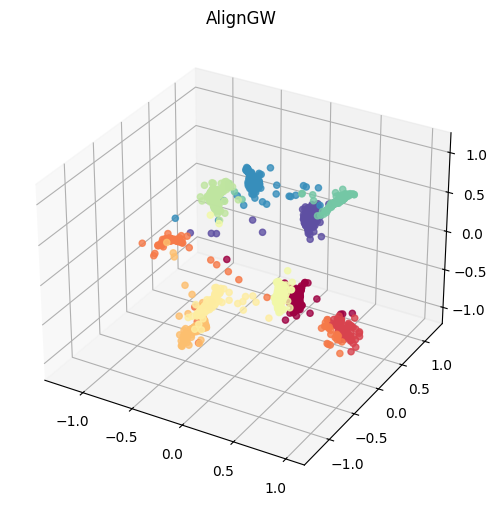

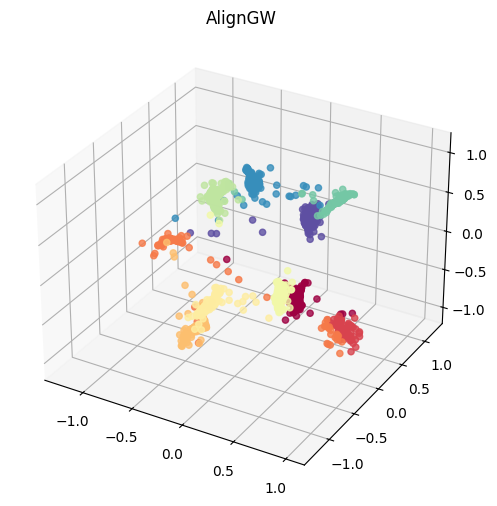

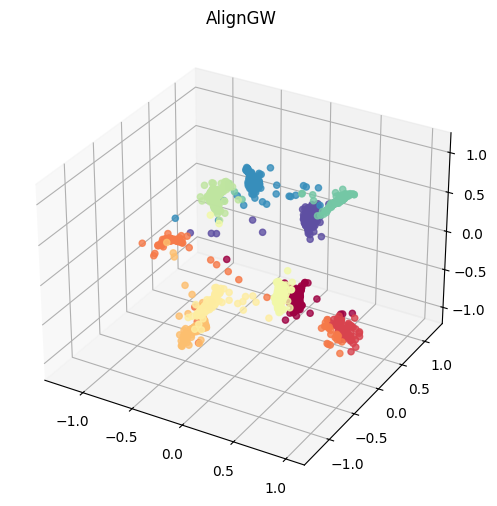

Interrumpting by keyboard...


In [9]:
trained_class = train_toy_discrete(source_vectors, target_vectors, labels,
                                   config, axis_lims=None, 
                                   report_every=20)